# CNN+LSTM Model - Dataset m01
## 5-Class Speech Emotion Recognition

**Classes:** angry, disgust, fear, sad, neutral

**Dataset:** data_features_m01.csv

**Architecture:** CNN layers + Bidirectional LSTM + Dense layers

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Dense, Conv1D, MaxPooling1D, LSTM, 
                                   Dropout, BatchNormalization, Flatten, 
                                   GlobalMaxPooling1D, Bidirectional)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

/Users/giangmytien/Desktop/KLTN/.venv2/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries imported successfully!


In [2]:
# Load and explore dataset m01
dataset_path = '../dataset step 3/data_features_m01.csv'
data = pd.read_csv(dataset_path)

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nLabel distribution:")
print(data['label'].value_counts())
print(f"\nFirst few rows:")
data.head()

Dataset shape: (4320, 41)

Columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', 'label']

Label distribution:
label
sad        960
angry      960
fear       960
disgust    960
neutral    480
Name: count, dtype: int64

First few rows:


,0,1,2,3,4,5,6,7,8,9,...,31,32,33,34,35,36,37,38,39,label
0,-694.231506,50.040554,0.552267,14.545629,3.444762,-2.469327,-3.988867,-10.599405,-7.204890,1.954130,...,-2.288055,-2.360345,-0.095407,-4.405079,-1.800773,-4.493698,-1.277828,-2.576992,-3.165682,neutral
1,-469.682239,24.812481,4.376637,7.737900,1.735599,-2.431461,-5.189324,-9.094118,-6.905061,-2.111880,...,-1.699113,-1.246151,-1.377645,-2.539707,-1.537789,-2.144637,-1.753057,-1.661558,-2.266360,neutral
2,-693.813782,49.947689,0.508969,14.515021,3.444183,-2.481389,-3.980087,-10.598415,-7.220357,1.961650,...,-2.284818,-2.349918,-0.105782,-4.420014,-1.789514,-4.494311,-1.271694,-2.580723,-3.176553,neutral
3,-706.712158,47.825089,-0.674069,14.761738,2.468847,-4.197237,-6.947045,-11.992122,-5.492224,1.690096,...,-1.509774,-1.567980,-2.817490,-4.761173,-2.271072,-4.018981,-0.811464,-4.686175,-2.178420,neutral
4,-706.450291,51.669993,-0.672582,11.109251,0.728495,-3.095116,-7.086010,-14.615463,-9.870567,2.474204,...,-1.227616,-1.464897,1.881643,-2.496609,-1.416349,-3.118476,0.819272,-2.767044,-3.644269,neutral


In [3]:
# Data preprocessing
# Filter for 5 classes only
target_classes = ['angry', 'disgust', 'fear', 'sad', 'neutral']
data_filtered = data[data['label'].isin(target_classes)].copy()

print(f"Filtered dataset shape: {data_filtered.shape}")
print(f"\nClass distribution after filtering:")
label_counts = data_filtered['label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(data_filtered)) * 100
    print(f"   {label}: {count} samples ({percentage:.1f}%)")

# Prepare features and labels
X = data_filtered.drop('label', axis=1).values
y = data_filtered['label'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Filtered dataset shape: (4320, 41)

Class distribution after filtering:
   sad: 960 samples (22.2%)
   angry: 960 samples (22.2%)
   fear: 960 samples (22.2%)
   disgust: 960 samples (22.2%)
   neutral: 480 samples (11.1%)

Features shape: (4320, 40)
Number of features: 40
Classes: ['angry' 'disgust' 'fear' 'neutral' 'sad']
Number of classes: 5


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for CNN+LSTM input (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Reshaped train data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"Categorical labels shape: {y_train_cat.shape}")

Train samples: 3456
Test samples: 864
Reshaped train data: (3456, 40, 1)
Reshaped test data: (864, 40, 1)
Categorical labels shape: (3456, 5)


In [5]:
# Create CNN+LSTM model
def create_cnn_lstm_model(input_shape, num_classes=5):
    """
    Create CNN+LSTM model for speech emotion recognition
    
    Architecture:
    1. Convolutional layers for local feature extraction
    2. LSTM layers for temporal modeling
    3. Dense layers for classification
    """
    
    inputs = Input(shape=input_shape, name='input')
    
    # CNN Block 1
    x = Conv1D(64, kernel_size=3, activation='relu', padding='same', name='conv1d_1')(inputs)
    x = BatchNormalization(name='bn_1')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_1')(x)
    x = Dropout(0.25, name='dropout_1')(x)
    
    # CNN Block 2
    x = Conv1D(128, kernel_size=3, activation='relu', padding='same', name='conv1d_2')(x)
    x = BatchNormalization(name='bn_2')(x)
    x = MaxPooling1D(pool_size=2, name='maxpool_2')(x)
    x = Dropout(0.25, name='dropout_2')(x)
    
    # CNN Block 3
    x = Conv1D(256, kernel_size=3, activation='relu', padding='same', name='conv1d_3')(x)
    x = BatchNormalization(name='bn_3')(x)
    x = Dropout(0.25, name='dropout_3')(x)
    
    # LSTM Blocks
    x = Bidirectional(LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.3), name='bilstm_1')(x)
    x = Bidirectional(LSTM(64, dropout=0.3, recurrent_dropout=0.3), name='bilstm_2')(x)
    
    # Dense layers
    x = Dense(256, activation='relu', name='dense_1')(x)
    x = BatchNormalization(name='bn_final')(x)
    x = Dropout(0.5, name='dropout_final')(x)
    
    x = Dense(128, activation='relu', name='dense_2')(x)
    x = Dropout(0.3, name='dropout_dense')(x)
    
    # Output layer
    outputs = Dense(num_classes, activation='softmax', name='output')(x)
    
    model = Model(inputs, outputs, name='CNN_LSTM_EmotionRecognition')
    return model

# Build model
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
model = create_cnn_lstm_model(input_shape)

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN+LSTM model created and compiled!")
model.summary()

CNN+LSTM model created and compiled!


Model: "CNN_LSTM_EmotionRecognition"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 40, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 40, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_1 (MaxPooling1D)        │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 20, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 20, 128)        │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ maxpool_2 (MaxPooling1D)        │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 10, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 10, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 10, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_final (BatchNormalization)   │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_final (Dropout)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_dense (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 751,493 (2.87 MB)

 Trainable params: 750,085 (2.86 MB)

 Non-trainable params: 1,408 (5.50 KB)

In [6]:
# Training
print("Starting training...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    'best_cnn_lstm_m01.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

# Train model
history = model.fit(
    X_train_reshaped, y_train_cat,
    validation_data=(X_test_reshaped, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr, model_checkpoint],
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2309 - loss: 2.1649
Epoch 1: val_accuracy improved from -inf to 0.22917, saving model to best_cnn_lstm_m01.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.2311 - loss: 2.1636 - val_accuracy: 0.2292 - val_loss: 1.5981 - learning_rate: 0.0010
Epoch 2/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.2995 - loss: 1.7477
Epoch 2: val_accuracy improved from 0.22917 to 0.24884, saving model to best_cnn_lstm_m01.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.2997 - loss: 1.7468 - val_accuracy: 0.2488 - val_loss: 1.5928 - learning_rate: 0.0010
Epoch 3/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.3656 - loss: 1.5400
Epoch 3: val_accuracy improved from 0.24884 to 0.27894, saving model to best_cnn_lstm_m01.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.3656 - loss: 1.5397 - val_accuracy: 0.2789 - val_loss: 1.5829 - learning_rate: 0.0010
Epoch 4/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.4103 - loss: 1.4239
Epoch 4: val_accuracy improved from 0.27894 to 0.42130, saving model to best_cnn_lstm_m01.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.4106 - loss: 1.4232 - val_accuracy: 0.4213 - val_loss: 1.3517 - learning_rate: 0.0010
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.4611 - loss: 1.3172
Epoch 5: val_accuracy improved from 0.42130 to 0.50579, saving model to best_cnn_lstm_m01.h5


...

108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9401 - loss: 0.1763 - val_accuracy: 0.8935 - val_loss: 0.3848 - learning_rate: 5.0000e-04
Epoch 50/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9343 - loss: 0.1946
Epoch 50: val_accuracy did not improve from 0.89352
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9343 - loss: 0.1944 - val_accuracy: 0.8796 - val_loss: 0.4061 - learning_rate: 5.0000e-04
Epoch 51/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9388 - loss: 0.1814
Epoch 51: val_accuracy did not improve from 0.89352
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9388 - loss: 0.1814 - val_accuracy: 0.8912 - val_loss: 0.3711 - learning_rate: 5.0000e-04
Epoch 52/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9519 - loss: 0.1408
Epoch 52: val_accuracy improved from 0.89352 to 0.89583, saving model to best_cnn_lstm_m01.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9519 - loss: 0.1408 - val_accuracy: 0.8958 - val_loss: 0.3686 - learning_rate: 5.0000e-04
Epoch 53/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9405 - loss: 0.1578
Epoch 53: val_accuracy improved from 0.89583 to 0.90278, saving model to best_cnn_lstm_m01.h5


108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9405 - loss: 0.1577 - val_accuracy: 0.9028 - val_loss: 0.3481 - learning_rate: 5.0000e-04
Epoch 54/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9454 - loss: 0.1390
Epoch 54: val_accuracy did not improve from 0.90278
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9454 - loss: 0.1390 - val_accuracy: 0.8958 - val_loss: 0.3742 - learning_rate: 5.0000e-04
Epoch 55/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9504 - loss: 0.1410
Epoch 55: val_accuracy did not improve from 0.90278
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9504 - loss: 0.1409 - val_accuracy: 0.9005 - val_loss: 0.3872 - learning_rate: 5.0000e-04
Epoch 56/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9503 - loss: 0.1458
Epoch 56: val_accuracy did not improve from 0.90278
108/108 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9503 - loss: 0.1458 - val_accuracy: 0.8900 - val_loss: 0.3820 - learning_rate: 5.00

108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9530 - loss: 0.1309 - val_accuracy: 0.9051 - val_loss: 0.3744 - learning_rate: 5.0000e-04
Epoch 61/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9502 - loss: 0.1432
Epoch 61: val_accuracy did not improve from 0.90509
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9502 - loss: 0.1430 - val_accuracy: 0.8819 - val_loss: 0.4307 - learning_rate: 5.0000e-04
Epoch 62/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9545 - loss: 0.1351
Epoch 62: val_accuracy did not improve from 0.90509
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9546 - loss: 0.1351 - val_accuracy: 0.8958 - val_loss: 0.3726 - learning_rate: 5.0000e-04
Epoch 63/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9558 - loss: 0.1217
Epoch 63: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 63: val_accuracy did not improve from 0.90509
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - accuracy: 0.9557 

108/108 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - accuracy: 0.9798 - loss: 0.0654 - val_accuracy: 0.9074 - val_loss: 0.3868 - learning_rate: 1.2500e-04
Epoch 77/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9744 - loss: 0.0753
Epoch 77: val_accuracy did not improve from 0.90741
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - accuracy: 0.9745 - loss: 0.0752 - val_accuracy: 0.9005 - val_loss: 0.3954 - learning_rate: 1.2500e-04
Epoch 78/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.9748 - loss: 0.0704
Epoch 78: val_accuracy did not improve from 0.90741
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.9748 - loss: 0.0704 - val_accuracy: 0.9016 - val_loss: 0.3915 - learning_rate: 1.2500e-04
Epoch 79/100
107/108 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9696 - loss: 0.0796
Epoch 79: val_accuracy did not improve from 0.90741
108/108 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.9697 - loss: 0.0795 - val_accuracy: 0.9062 - val_loss: 0.3832 - learning_rate: 1.2

In [7]:
# Evaluation and Results
print("CNN+LSTM MODEL EVALUATION - Dataset m01")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_reshaped, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification Report
print(f"\nCLASSIFICATION REPORT:")
print("-" * 50)
class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")

# Training Summary
epochs_trained = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nTRAINING SUMMARY:")
print("-" * 50)
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Final Training Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")
print(f"Epochs Trained: {epochs_trained}")

CNN+LSTM MODEL EVALUATION - Dataset m01
Test Accuracy: 0.9074
Test Loss: 0.3868

CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

       angry     0.9767    0.8750    0.9231       192
     disgust     0.8806    0.9219    0.9008       192
        fear     0.9031    0.9219    0.9124       192
     neutral     0.8431    0.8958    0.8687        96
         sad     0.9119    0.9167    0.9143       192

    accuracy                         0.9074       864
   macro avg     0.9031    0.9062    0.9038       864
weighted avg     0.9098    0.9074    0.9077       864


Cohen's Kappa Score: 0.8829

TRAINING SUMMARY:
--------------------------------------------------
Final Training Accuracy: 0.9795
Final Validation Accuracy: 0.9062
Final Training Loss: 0.0675
Final Validation Loss: 0.3922
Epochs Trained: 96


In [9]:
import joblib
joblib.dump(scaler, "/Users/giangmytien/Desktop/KLTN/Demo app/models cnn lstm/scaler.pkl")
joblib.dump(label_encoder, "/Users/giangmytien/Desktop/KLTN/Demo app/models cnn lstm/label_encoder.pkl")
print("Saved! Classes:", list(label_encoder.classes_))
print("Scaler mean[0]:", round(scaler.mean_[0], 2))


Saved! Classes: ['angry', 'disgust', 'fear', 'neutral', 'sad']
Scaler mean[0]: -528.12



CONFUSION MATRIX:
--------------------------------------------------
Predicted ->
True    angry     disgust   fear      neutral   sad       
angry   168       16        3         3         2         
disgust 0         177       9         3         3         
fear    3         3         177       1         8         
neutral 0         4         2         86        4         
sad     1         1         5         9         176       


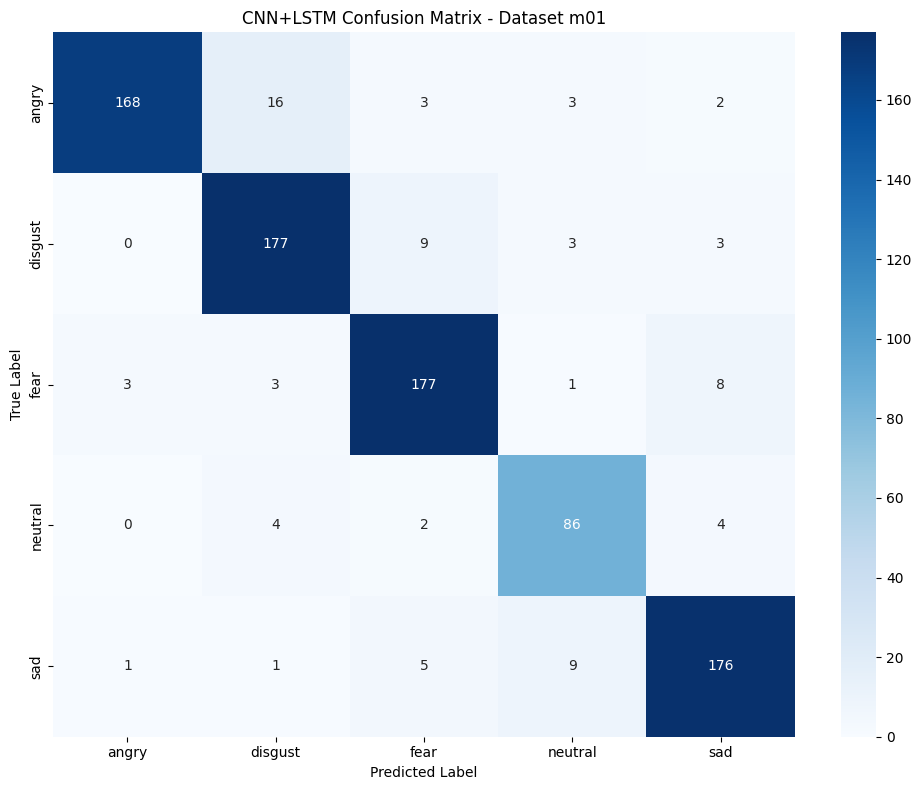

In [10]:
# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix in text format
print("Predicted ->")
print(f"{'True':<8}", end="")
for class_name in class_names:
    print(f"{class_name:<10}", end="")
print()

for i, class_name in enumerate(class_names):
    print(f"{class_name:<8}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i,j]:<10}", end="")
    print()

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('CNN+LSTM Confusion Matrix - Dataset m01')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

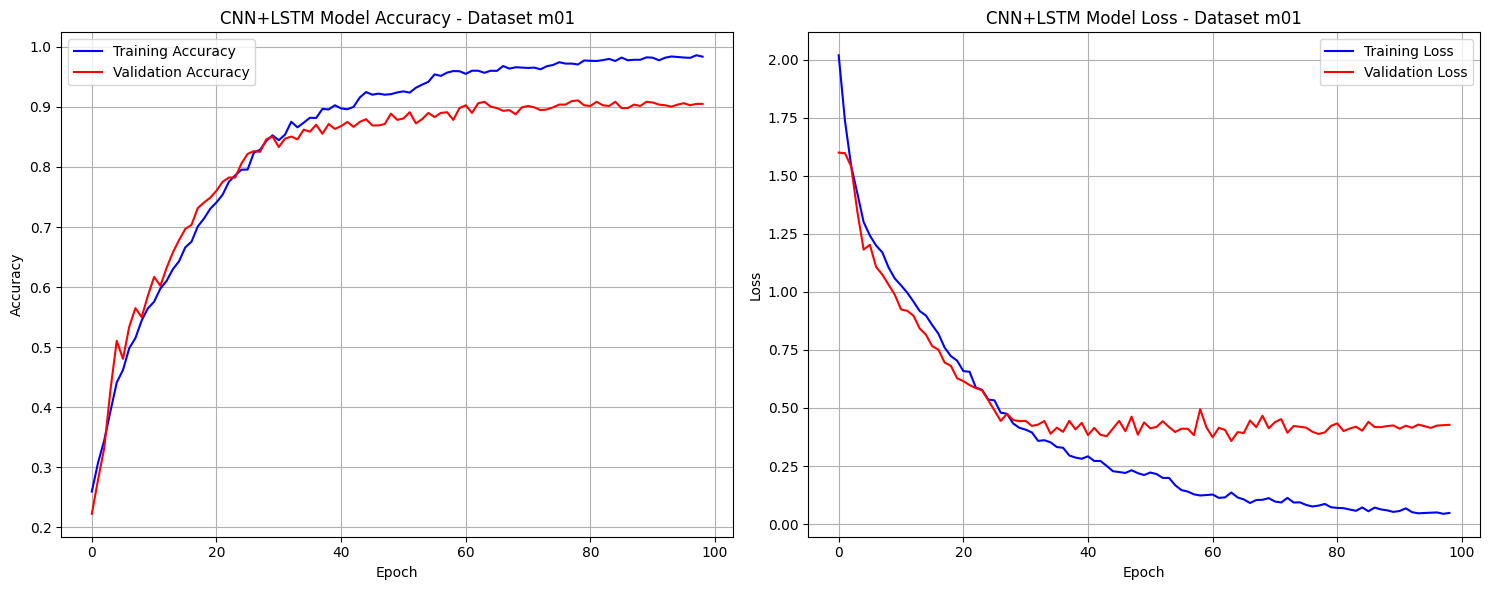

Training history plots generated!


In [9]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('CNN+LSTM Model Accuracy - Dataset m01')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('CNN+LSTM Model Loss - Dataset m01')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")

In [ ]:
# Final summary
print(f"\nFINAL RESULTS SUMMARY - CNN+LSTM m01")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {epochs_trained}")
print(f"Dataset: data_features_m01.csv")
print(f"Classes: {', '.join(class_names)}")


FINAL RESULTS SUMMARY - CNN+LSTM m01
Test Accuracy: 0.9109
Cohen's Kappa: 0.8874
Epochs Trained: 99
Dataset: data_features_m01.csv
Classes: angry, disgust, fear, neutral, sad


: 